In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt
import numpy as np

In [13]:
df_all = pd.read_csv('photoelectric_data.csv')

In [4]:
df_all.head()

,Voltage (V),Voltage unc,Current (nA),Current unc (nA),Filter (nm),Filter unc (nm)
0,0.00,0.003,2.2900,0.0100,365.0,2.0
1,0.50,0.003,1.0100,0.0100,365.0,2.0
2,1.00,0.003,0.1890,0.0020,365.0,2.0
3,1.10,0.003,0.0874,0.0001,365.0,2.0
4,1.15,0.003,0.0472,0.0002,365.0,2.0


In [11]:
def two_piece_linear(x, x0, k, b):
    return np.where(x < x0, k*x + b, k*x0 + b)

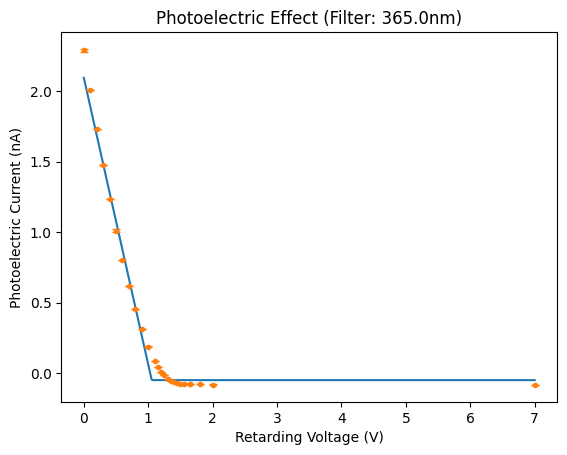

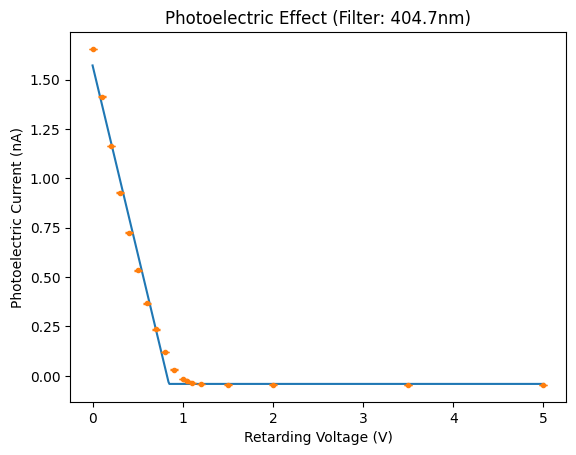

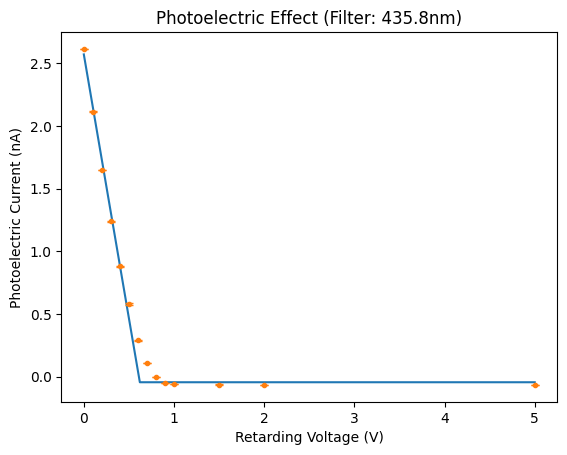

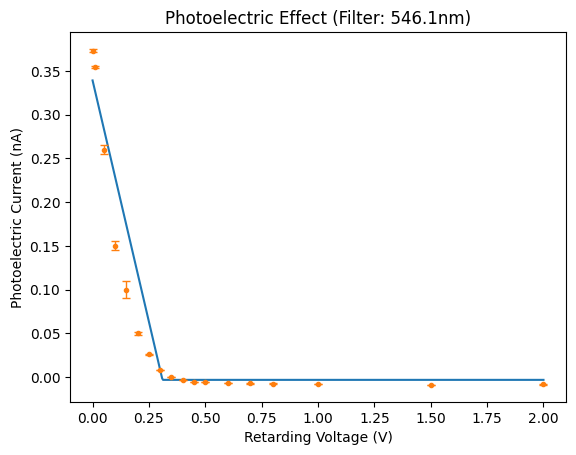

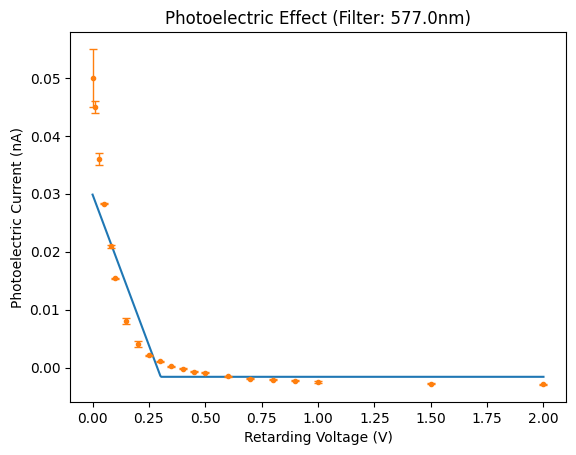

In [14]:
filters = df_all['Filter (nm)'].unique()
for filter in filters:
    df = df_all[df_all['Filter (nm)'] == filter]
    x = df['Voltage (V)']
    x_err = [0.01/12**0.5] * len(df)
    y = df['Current (nA)']
    y_err = df['Current unc (nA)']

    popt, pcov = opt.curve_fit(f=two_piece_linear,
                           xdata=x,
                           ydata=y,
                           sigma=y_err,
                        #    p0=[10,1,10,1,60,60], # Initial guess for params
                           absolute_sigma=True,
                           maxfev = 20000) # Fit function

    uncert = np.sqrt(np.diag(pcov))

    x = np.linspace(start=min(x),stop=max(x),num=500,endpoint=True) # Define x for smoother plotting of our poisson fit function

    plt.plot(x, two_piece_linear(x, *popt), label='Fit') # Plot fit function

    plt.errorbar(df['Voltage (V)'], df['Current (nA)'], yerr=df['Current unc (nA)'], linewidth=1, ls='none', fmt='o', capsize=3, ms=3, label = 'Experimental Data') # Plot actual data


    plt.xlabel('Retarding Voltage (V)')
    plt.ylabel('Photoelectric Current (nA)')
    plt.title(f'Photoelectric Effect (Filter: {filter}nm)')
    plt.show()
    plt.close('all')